## Bibliotecas

In [1]:
#import packages
import pandas as pd
import numpy as np
import os
import warnings
import optuna
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
import shap
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

## Configurações

In [2]:
# Definir diretório
os.chdir('/home/joao/Área de Trabalho/tese')

# Evitar avisos
warnings.filterwarnings('ignore')

In [3]:
#load dataset
df = pd.read_excel('df_conjunto_rio.xlsx')

In [4]:
#rename columns
df = df.rename(columns={
    'semana':'week',
    'cesta_dieese':'dieese_basket',
    'carne':'meat',
    'leite':'milk',
    'feijao':'bean',
    'arroz':'rice',
    'farinha':'flour',
    'batata':'potato',
    'tomate':'tomato',
    'pao':'bread',
    'cafe':'coffee',
    'acucar':'sugar',
    'oleo':'lard/oil',
    'manteiga':'butter',
    'cesta_online':'online'
})

In [5]:
df.columns

Index(['week', 'dieese_basket', 'meat', 'milk', 'bean', 'rice', 'flour',
       'potato', 'tomato', 'bread', 'coffee', 'banana', 'sugar', 'lard/oil',
       'butter', 'online'],
      dtype='object')

In [6]:
#create lagged dataset
k = 1 #number of lags
y_lag = df[['week','dieese_basket']][k:]
x_lag = df.copy()
x_lag = x_lag.drop(['week','dieese_basket'], axis=1)
x_lag = x_lag[:len(df)-k]
y_lag = y_lag.reset_index(drop=True)
x_lag = x_lag.reset_index(drop=True)
df_lag = pd.concat([y_lag,x_lag], axis=1)

In [7]:
#set X and y
X = df_lag.copy()
X = X.drop(['week','dieese_basket','online'], axis=1)
y = df_lag['dieese_basket'] 

In [8]:
def calculate_mape(y_true, y_pred):
    mask = y_true != 0
    if mask.sum() == 0:
        return 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

## Random forest

In [9]:
#function Optuna -- RF
def objective(trial):
    # 1. Define hyperparameters to tune
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_leaf_nodes = trial.suggest_int('max_leaf_nodes', 2, 256)
    min_samples_split = trial.suggest_int('min_samples_split', 5, 100)
    max_depth = trial.suggest_int('max_depth', 5, 20, log=True)
    
    # 2. Expanding window parameters
    initial_train_size = 10  # Starting length of training data
    step_size = 1            # How much to expand the window per step
    total_samples = len(X)
    
    scores = []
    
    # 3. Walk-forward expanding window loop
    for train_end in range(initial_train_size, total_samples, step_size):
        X_train = X[:train_end]
        y_train = y[:train_end]
        
        # Validation window directly follows the training window
        X_val = X[train_end:train_end + step_size]
        y_val = y[train_end:train_end + step_size]
        
        if len(y_val) == 0:
            break
            
        # 4. Train and predict
        model = RandomForestRegressor(
            n_estimators=n_estimators,
            max_leaf_nodes=max_leaf_nodes,
            min_samples_split=min_samples_split,
            max_depth=max_depth,
            random_state=42
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        
        # 5. Evaluate and store score
        rmse = root_mean_squared_error(y_val, preds)
        scores.append(rmse)
        
    # Return the mean error across all expanding window splits
    return np.mean(scores)

In [10]:
#run Optuna RF
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20)

[I 2026-06-29 16:46:59,856] A new study created in memory with name: no-name-fbd79d29-39ef-431d-a3cc-c2b2f822370a
[I 2026-06-29 16:47:02,993] Trial 0 finished with value: 28.77094549596124 and parameters: {'n_estimators': 106, 'max_leaf_nodes': 244, 'min_samples_split': 75, 'max_depth': 11}. Best is trial 0 with value: 28.77094549596124.
[I 2026-06-29 16:47:05,310] Trial 1 finished with value: 13.156693558639011 and parameters: {'n_estimators': 73, 'max_leaf_nodes': 41, 'min_samples_split': 10, 'max_depth': 17}. Best is trial 1 with value: 13.156693558639011.
[I 2026-06-29 16:47:09,727] Trial 2 finished with value: 11.990507096134303 and parameters: {'n_estimators': 140, 'max_leaf_nodes': 182, 'min_samples_split': 6, 'max_depth': 20}. Best is trial 2 with value: 11.990507096134303.
[I 2026-06-29 16:47:14,542] Trial 3 finished with value: 21.258517366394962 and parameters: {'n_estimators': 175, 'max_leaf_nodes': 56, 'min_samples_split': 22, 'max_depth': 6}. Best is trial 2 with value: 1

In [11]:
#best hyperparameters RF
print("Best hyperparameters: ", study.best_params)

Best hyperparameters:  {'n_estimators': 194, 'max_leaf_nodes': 144, 'min_samples_split': 5, 'max_depth': 19}


In [12]:
# Treinar modelo final
best_model = RandomForestRegressor(
    n_estimators=study.best_params['n_estimators'],
    max_leaf_nodes=study.best_params['max_leaf_nodes'],
    min_samples_split=study.best_params['min_samples_split'],
    max_depth=study.best_params['max_depth'],
    random_state=42
)

best_model.fit(X, y)
y_pred = best_model.predict(X)

# Calcular métricas
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)
mape = calculate_mape(y, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"MAPE: {mape:.4f}%")

RMSE: 5.0304
MAE:  2.9713
MAPE: 0.3755%


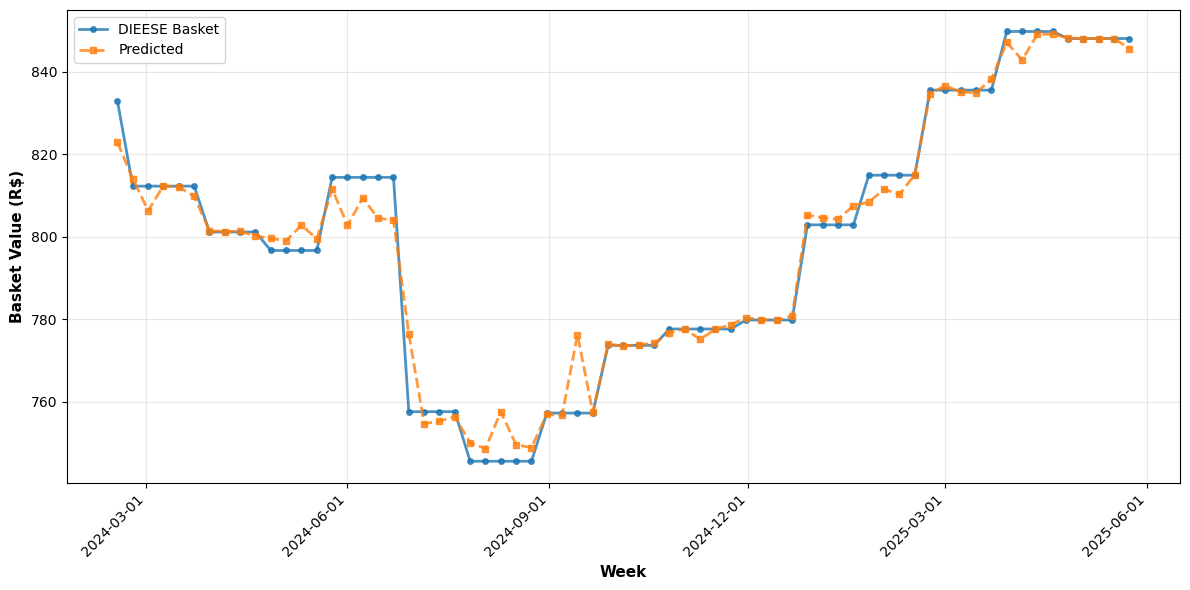

In [13]:
# Pegar datas originais do DataFrame (alinhadas com y)
dates = pd.to_datetime(df['week'].values[:len(y)])
 
# Gráfico de Série Temporal
plt.figure(figsize=(12, 6))
plt.plot(dates, y, 'o-', label='DIEESE Basket', linewidth=2, markersize=4, color='#1f77b4', alpha=0.8)
plt.plot(dates, y_pred, 's--', label='Predicted', linewidth=2, markersize=4, color='#ff7f0e', alpha=0.8)
plt.xlabel('Week', fontsize=11, fontweight='bold')
plt.ylabel('Basket Value (R$)', fontsize=11, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
 
# Formatar datas no eixo X
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')
 
plt.tight_layout()
plt.show()

In [14]:
# Valores shapĺey
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X)

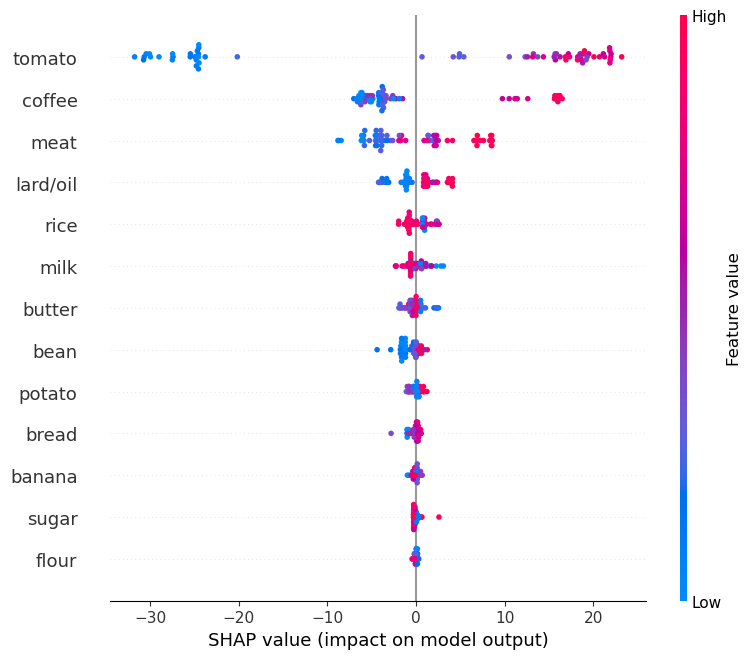

In [15]:
# shap beer plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, plot_type="dot", show=False)
plt.tight_layout()
plt.show()

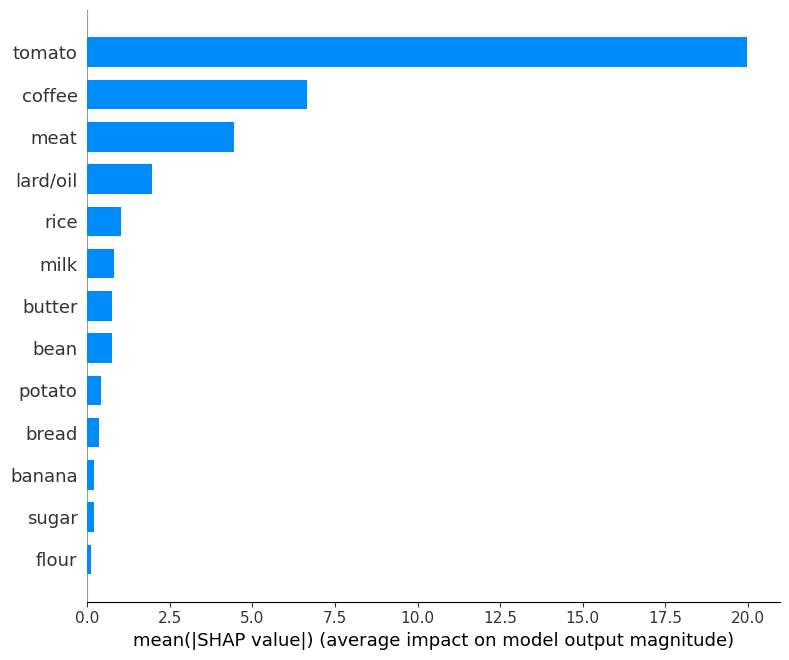

In [16]:
# shap bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

## Ridge

In [17]:
#function Optuna -- Ridge
def objective(trial):
    # 1. Define hyperparameters to tune
    alpha = trial.suggest_float('alpha', 1e-5, 1e2, log=True)
        
    # 2. Expanding window parameters
    initial_train_size = 10  # Starting length of training data
    step_size = 1            # How much to expand the window per step
    total_samples = len(X)
    
    scores = []
    
    # 3. Walk-forward expanding window loop
    for train_end in range(initial_train_size, total_samples, step_size):
        X_train = X[:train_end]
        y_train = y[:train_end]
        
        # Validation window directly follows the training window
        X_val = X[train_end:train_end + step_size]
        y_val = y[train_end:train_end + step_size]
        
        if len(y_val) == 0:
            break
            
        # 4. Train and predict
        model = Ridge(
            alpha=alpha,
            random_state=42
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        
        # 5. Evaluate and store score
        rmse = root_mean_squared_error(y_val, preds)
        scores.append(rmse)
        
    # Return the mean error across all expanding window splits
    return np.mean(scores)

In [18]:
#run Optuna Ridge
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20)

[I 2026-06-29 16:48:24,572] A new study created in memory with name: no-name-3c7cc469-bb9a-41e3-9391-479ca75c09cf
[I 2026-06-29 16:48:24,707] Trial 0 finished with value: 16.18389439715612 and parameters: {'alpha': 0.004185822729546971}. Best is trial 0 with value: 16.18389439715612.
[I 2026-06-29 16:48:24,825] Trial 1 finished with value: 13.090633208522824 and parameters: {'alpha': 45.18560951024108}. Best is trial 1 with value: 13.090633208522824.
[I 2026-06-29 16:48:24,913] Trial 2 finished with value: 12.635657380002293 and parameters: {'alpha': 1.330324510152291}. Best is trial 2 with value: 12.635657380002293.
[I 2026-06-29 16:48:25,003] Trial 3 finished with value: 13.114769884403932 and parameters: {'alpha': 0.1550991398759431}. Best is trial 2 with value: 12.635657380002293.
[I 2026-06-29 16:48:25,106] Trial 4 finished with value: 18.42198255037062 and parameters: {'alpha': 0.000123631882770522}. Best is trial 2 with value: 12.635657380002293.
[I 2026-06-29 16:48:25,205] Tria

In [19]:
#best hyperparameters Ridge
print("Best hyperparameters: ", study.best_params)

Best hyperparameters:  {'alpha': 6.512613790583885}


In [20]:
# Treinar modelo final
best_model = Ridge(
    alpha=study.best_params['alpha'],
    random_state=42
)

best_model.fit(X, y)
y_pred = best_model.predict(X)

# Calcular métricas
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)
mape = calculate_mape(y, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"MAPE: {mape:.4f}%")

RMSE: 10.5309
MAE:  8.7573
MAPE: 1.0996%


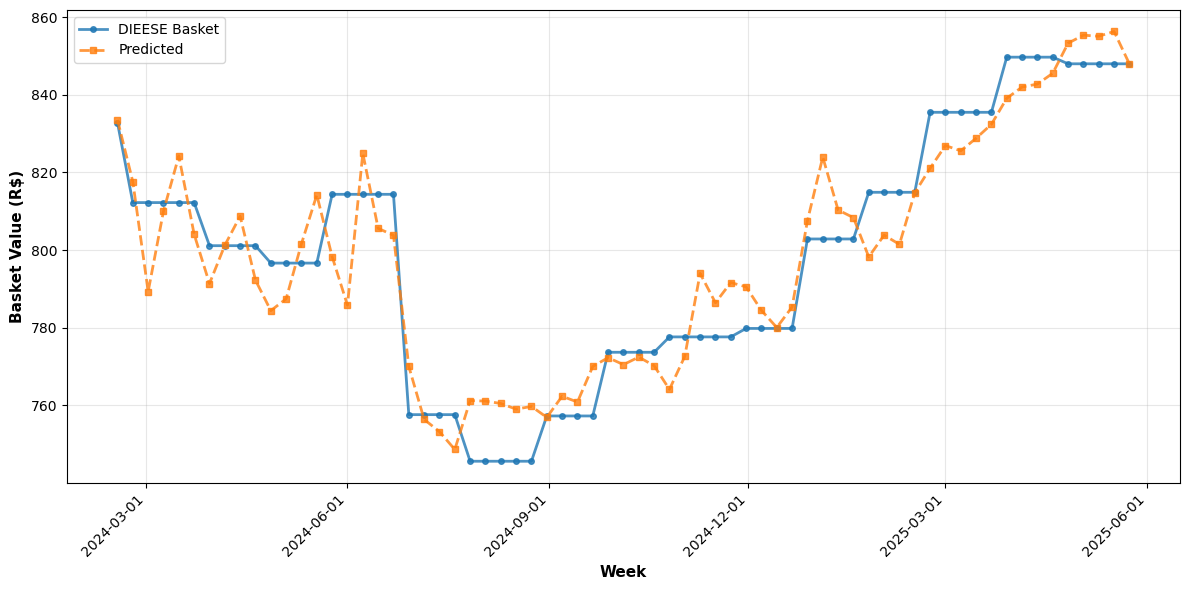

In [21]:
# Pegar datas originais do DataFrame (alinhadas com y)
dates = pd.to_datetime(df['week'].values[:len(y)])
 
# Gráfico de Série Temporal
plt.figure(figsize=(12, 6))
plt.plot(dates, y, 'o-', label='DIEESE Basket', linewidth=2, markersize=4, color='#1f77b4', alpha=0.8)
plt.plot(dates, y_pred, 's--', label='Predicted', linewidth=2, markersize=4, color='#ff7f0e', alpha=0.8)
plt.xlabel('Week', fontsize=11, fontweight='bold')
plt.ylabel('Basket Value (R$)', fontsize=11, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
 
# Formatar datas no eixo X
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')
 
plt.tight_layout()
plt.show()

Ao executa o explainer abaixo gerou erro para o algoritmo `Ridge`. InvalidModelError: Model type not yet supported by TreeExplainer: <class 'sklearn.linear_model._ridge.Ridge'>

In [22]:
# Valores shapĺey
# explainer = shap.TreeExplainer(best_model)
# shap_values = explainer.shap_values(X)

## KNN

In [23]:
#function Optuna -- kNN
def objective(trial):
    # 1. Define hyperparameters to tune
    n_neighbors = trial.suggest_int('n_neighbors', 1, 10)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    metric = trial.suggest_categorical('metric', ['euclidean', 'manhattan'])
        
    # 2. Expanding window parameters
    initial_train_size = 10  # Starting length of training data
    step_size = 1            # How much to expand the window per step
    total_samples = len(X)
    
    scores = []
    
    # 3. Walk-forward expanding window loop
    for train_end in range(initial_train_size, total_samples, step_size):
        X_train = X[:train_end]
        y_train = y[:train_end]
        
        # Validation window directly follows the training window
        X_val = X[train_end:train_end + step_size]
        y_val = y[train_end:train_end + step_size]
        
        if len(y_val) == 0:
            break
            
        # 4. Train and predict
        model = KNeighborsRegressor(
            n_neighbors=n_neighbors,
            weights=weights,
            metric=metric
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        
        # 5. Evaluate and store score
        rmse = root_mean_squared_error(y_val, preds)
        scores.append(rmse)
        
    # Return the mean error across all expanding window splits
    return np.mean(scores)

In [24]:
#run Optuna knn
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20)

[I 2026-06-29 16:48:26,611] A new study created in memory with name: no-name-17e38883-bab4-4847-8578-b8aac9efe60c
[I 2026-06-29 16:48:26,712] Trial 0 finished with value: 11.55434210526316 and parameters: {'n_neighbors': 4, 'weights': 'uniform', 'metric': 'euclidean'}. Best is trial 0 with value: 11.55434210526316.
[I 2026-06-29 16:48:26,804] Trial 1 finished with value: 6.238484220494245 and parameters: {'n_neighbors': 2, 'weights': 'distance', 'metric': 'manhattan'}. Best is trial 1 with value: 6.238484220494245.
[I 2026-06-29 16:48:26,896] Trial 2 finished with value: 5.342982456140354 and parameters: {'n_neighbors': 1, 'weights': 'uniform', 'metric': 'euclidean'}. Best is trial 2 with value: 5.342982456140354.
[I 2026-06-29 16:48:26,988] Trial 3 finished with value: 7.42014059464714 and parameters: {'n_neighbors': 2, 'weights': 'distance', 'metric': 'euclidean'}. Best is trial 2 with value: 5.342982456140354.
[I 2026-06-29 16:48:27,101] Trial 4 finished with value: 13.0378040734653

In [25]:
#best hyperparameters knn
print("Best hyperparameters: ", study.best_params)

Best hyperparameters:  {'n_neighbors': 1, 'weights': 'uniform', 'metric': 'manhattan'}


In [26]:
# Treinar modelo final
best_model = KNeighborsRegressor(
    n_neighbors=study.best_params['n_neighbors'],
    weights=study.best_params['weights'],
    metric=study.best_params['metric']
)
best_model.fit(X, y)
y_pred = best_model.predict(X)

# Calcular métricas
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)
mape = calculate_mape(y, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"MAPE: {mape:.4f}%")

RMSE: 0.0000
MAE:  0.0000
MAPE: 0.0000%


## XGBoost

In [27]:
#function Optuna -- XGB
def objective(trial):
    # 1. Define hyperparameters to tune
    max_depth = trial.suggest_int('max_depth', 3, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.1)
    n_estimators = trial.suggest_int('n_estimators', 10, 200)
    subsample = trial.suggest_float('subsample', 0.5, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)
    min_child_weight = trial.suggest_int('min_child_weight', 1, 10)
    gamma = trial.suggest_float('gamma', 0, 5)
        
    # 2. Expanding window parameters
    initial_train_size = 10  # Starting length of training data
    step_size = 1            # How much to expand the window per step
    total_samples = len(X)
    
    scores = []
    
    # 3. Walk-forward expanding window loop
    for train_end in range(initial_train_size, total_samples, step_size):
        X_train = X[:train_end]
        y_train = y[:train_end]
        
        # Validation window directly follows the training window
        X_val = X[train_end:train_end + step_size]
        y_val = y[train_end:train_end + step_size]
        
        if len(y_val) == 0:
            break
            
        # 4. Train and predict
        model = XGBRegressor(
            max_depth = max_depth,
            learning_rate = learning_rate,
            n_estimators = n_estimators,
            subsample = subsample,
            colsample_bytree = colsample_bytree,
            min_child_weight = min_child_weight,
            gamma = gamma
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        
        # 5. Evaluate and store score
        rmse = root_mean_squared_error(y_val, preds)
        scores.append(rmse)
        
    # Return the mean error across all expanding window splits
    return np.mean(scores)

In [28]:
#run Optuna XGB
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20)

[I 2026-06-29 16:48:28,611] A new study created in memory with name: no-name-7a3a8ace-1dc0-4852-8b32-e3908f60955c
[I 2026-06-29 16:48:37,145] Trial 0 finished with value: 10.740836717036743 and parameters: {'max_depth': 5, 'learning_rate': 0.09556428757689246, 'n_estimators': 149, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 2, 'gamma': 0.2904180608409973}. Best is trial 0 with value: 10.740836717036743.
[I 2026-06-29 16:48:41,252] Trial 1 finished with value: 17.99951445997808 and parameters: {'max_depth': 9, 'learning_rate': 0.0641003510568888, 'n_estimators': 145, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'min_child_weight': 9, 'gamma': 1.0616955533913808}. Best is trial 0 with value: 10.740836717036743.
[I 2026-06-29 16:48:46,440] Trial 2 finished with value: 16.004791195518102 and parameters: {'max_depth': 4, 'learning_rate': 0.026506405886809047, 'n_estimators': 68, 'subsample': 0.762378215816119, 'col

In [29]:
#best hyperparameters Ridge
print("Best hyperparameters: ", study.best_params)

Best hyperparameters:  {'max_depth': 5, 'learning_rate': 0.09556428757689246, 'n_estimators': 149, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 2, 'gamma': 0.2904180608409973}


In [30]:
# Treinar modelo final
best_model = XGBRegressor(
    max_depth=study.best_params['max_depth'],
    learning_rate=study.best_params['learning_rate'],
    n_estimators=study.best_params['n_estimators'],
    subsample=study.best_params['subsample'],
    alpcolsample_bytreeha=study.best_params['colsample_bytree'],
    min_child_weight=study.best_params['min_child_weight'],
    gamma=study.best_params['gamma'],
    random_state=42
)

best_model.fit(X, y)
y_pred = best_model.predict(X)

# Calcular métricas
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)
mape = calculate_mape(y, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"MAPE: {mape:.4f}%")

RMSE: 0.2567
MAE:  0.1938
MAPE: 0.0244%


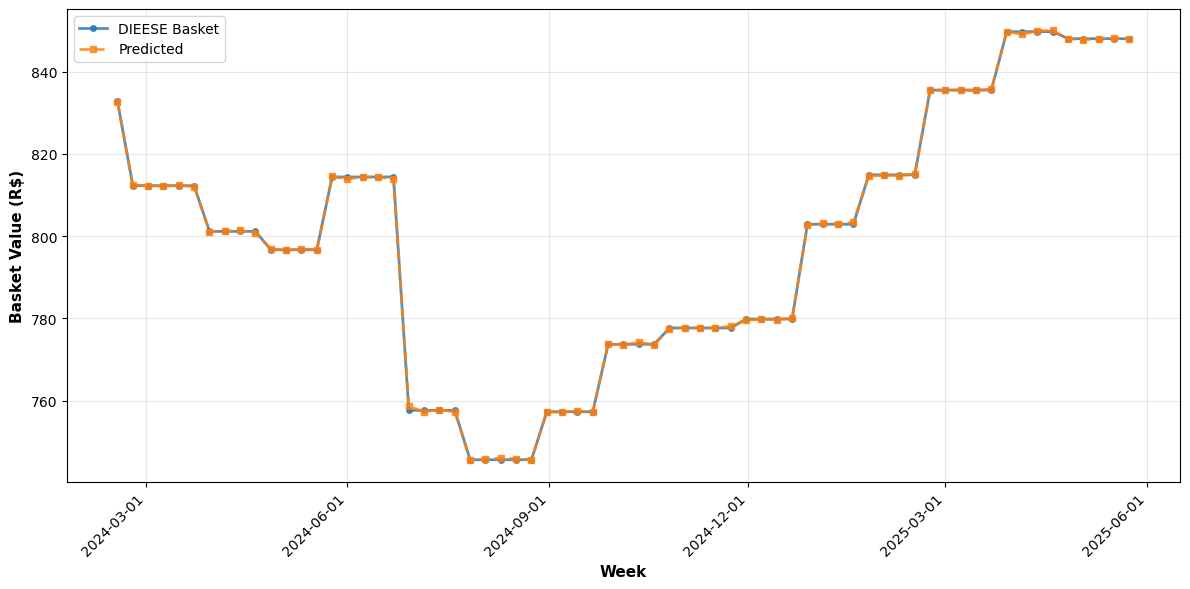

In [31]:
# Pegar datas originais do DataFrame (alinhadas com y)
dates = pd.to_datetime(df['week'].values[:len(y)])
 
# Gráfico de Série Temporal
plt.figure(figsize=(12, 6))
plt.plot(dates, y, 'o-', label='DIEESE Basket', linewidth=2, markersize=4, color='#1f77b4', alpha=0.8)
plt.plot(dates, y_pred, 's--', label='Predicted', linewidth=2, markersize=4, color='#ff7f0e', alpha=0.8)
plt.xlabel('Week', fontsize=11, fontweight='bold')
plt.ylabel('Basket Value (R$)', fontsize=11, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
 
# Formatar datas no eixo X
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')
 
plt.tight_layout()
plt.show()

In [32]:
# Valores shapĺey
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X)

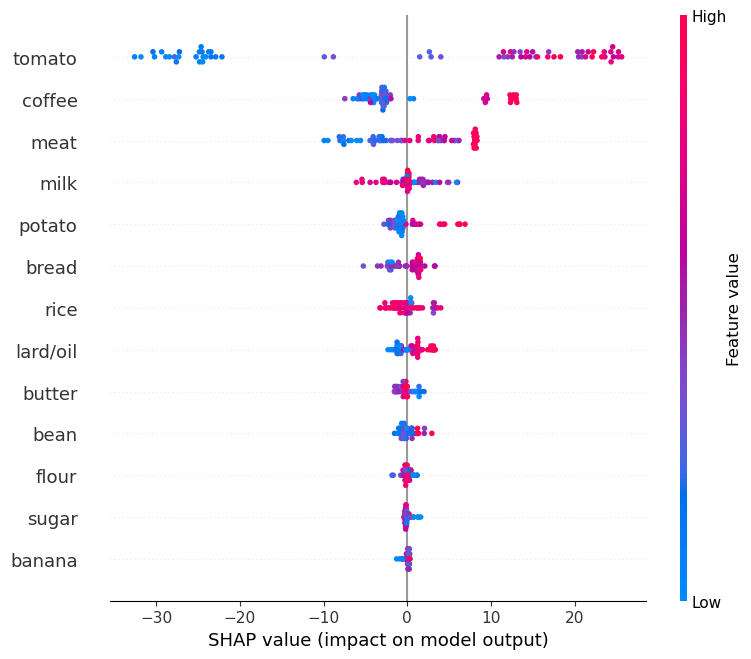

In [33]:
# shap beer plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, plot_type="dot", show=False)
plt.tight_layout()
plt.show()

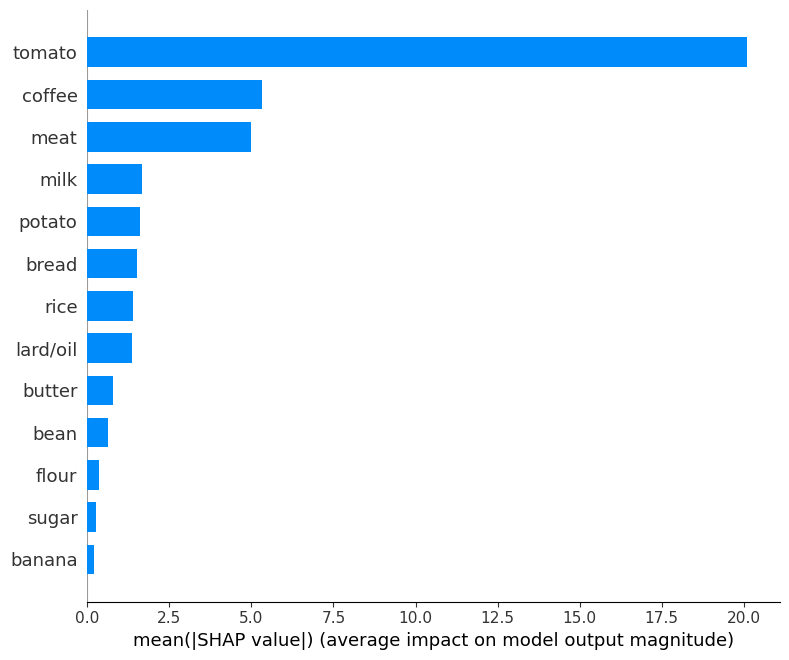

In [34]:
# shap bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

## VotinRegressor

In [35]:
#function Optuna -- Voting Regressor
def objective(trial):
    # 1. Define hyperparameters to tune
    rf_n_estimators = trial.suggest_int('rf_n_estimators', 50, 200)
    rf_max_leaf_nodes = trial.suggest_int('rf_max_leaf_nodes', 2, 256)
    rf_min_samples_split = trial.suggest_int('rf_min_samples_split', 5, 100)
    rf_max_depth = trial.suggest_int('rf_max_depth', 5, 20, log=True)
    
    ridge_alpha = trial.suggest_float('ridge_alpha', 0.1, 100)
    
    knn_neighbors = trial.suggest_int('knn_neighbors', 1, 10)
    knn_weights = trial.suggest_categorical('knn_weights', ['uniform', 'distance'])
    
    xgb_max_depth = trial.suggest_int('xgb_max_depth', 3, 10)
    xgb_learning_rate = trial.suggest_float('xgb_learning_rate', 0.01, 0.3)
    xgb_n_estimators = trial.suggest_int('xgb_n_estimators', 50, 200)
    
    # 2. Expanding window parameters
    initial_train_size = 10
    step_size = 1
    total_samples = len(X)
    
    scores = []
    
    # 3. Walk-forward expanding window loop
    for train_end in range(initial_train_size, total_samples, step_size):
        X_train = X[:train_end]
        y_train = y[:train_end]
        
        X_val = X[train_end:train_end + step_size]
        y_val = y[train_end:train_end + step_size]
        
        if len(y_val) == 0:
            break
            
        # 4. Train and predict
        rf_model = RandomForestRegressor(
            n_estimators=rf_n_estimators,
            max_leaf_nodes=rf_max_leaf_nodes,
            min_samples_split=rf_min_samples_split,
            max_depth=rf_max_depth,
            random_state=42
        )
        
        ridge_model = Ridge(alpha=ridge_alpha)
        
        knn_model = KNeighborsRegressor(
            n_neighbors=knn_neighbors,
            weights=knn_weights
        )
        
        xgb_model = XGBRegressor(
            max_depth=xgb_max_depth,
            learning_rate=xgb_learning_rate,
            n_estimators=xgb_n_estimators,
            random_state=42
        )
        
        voting_model = VotingRegressor(
            estimators=[('rf', rf_model), ('ridge', ridge_model), ('knn', knn_model), ('xgb', xgb_model)]
        )
        
        voting_model.fit(X_train, y_train)
        preds = voting_model.predict(X_val)
        
        # 5. Evaluate and store score
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        scores.append(rmse)
        
    # Return the mean error across all expanding window splits
    return np.mean(scores)

In [36]:
#run Optuna Voting Regressor
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20)

[I 2026-06-29 16:51:04,267] A new study created in memory with name: no-name-8ac32cc7-a2c0-499f-a03c-71485877fb97
[I 2026-06-29 16:51:11,695] Trial 0 finished with value: 12.490447038529185 and parameters: {'rf_n_estimators': 106, 'rf_max_leaf_nodes': 244, 'rf_min_samples_split': 75, 'rf_max_depth': 11, 'ridge_alpha': 15.686262180199408, 'knn_neighbors': 2, 'knn_weights': 'distance', 'xgb_max_depth': 7, 'xgb_learning_rate': 0.21534104756085318, 'xgb_n_estimators': 53}. Best is trial 0 with value: 12.490447038529185.
[I 2026-06-29 16:51:22,279] Trial 1 finished with value: 12.274549282947321 and parameters: {'rf_n_estimators': 196, 'rf_max_leaf_nodes': 214, 'rf_min_samples_split': 25, 'rf_max_depth': 6, 'ridge_alpha': 18.42211053435804, 'knn_neighbors': 4, 'knn_weights': 'uniform', 'xgb_max_depth': 5, 'xgb_learning_rate': 0.18743733946949004, 'xgb_n_estimators': 71}. Best is trial 1 with value: 12.274549282947321.
[I 2026-06-29 16:51:29,079] Trial 2 finished with value: 14.7575789762517

In [37]:
#best hyperparameters Voting Regressor
print("Best hyperparameters: ", study.best_params)

Best hyperparameters:  {'rf_n_estimators': 140, 'rf_max_leaf_nodes': 46, 'rf_min_samples_split': 5, 'rf_max_depth': 12, 'ridge_alpha': 64.99838039486436, 'knn_neighbors': 3, 'knn_weights': 'distance', 'xgb_max_depth': 6, 'xgb_learning_rate': 0.17355266271621556, 'xgb_n_estimators': 181}


In [38]:
# Treinar modelo final
best_model = VotingRegressor(
    estimators=[
        ('rf', RandomForestRegressor(
            n_estimators=study.best_params['rf_n_estimators'],
            max_leaf_nodes=study.best_params['rf_max_leaf_nodes'],
            min_samples_split=study.best_params['rf_min_samples_split'],
            max_depth=study.best_params['rf_max_depth'],
            random_state=42
        )),
        ('ridge', Ridge(alpha=study.best_params['ridge_alpha'])),
        ('knn', KNeighborsRegressor(
            n_neighbors=study.best_params['knn_neighbors'],
            weights=study.best_params['knn_weights']
        )),
        ('xgb', XGBRegressor(
            max_depth=study.best_params['xgb_max_depth'],
            learning_rate=study.best_params['xgb_learning_rate'],
            n_estimators=study.best_params['xgb_n_estimators'],
            random_state=42
        ))
    ]
)
 
best_model.fit(X, y)
y_pred = best_model.predict(X)

# Calcular métricas
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)
mape = calculate_mape(y, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"MAPE: {mape:.4f}%")

RMSE: 3.8490
MAE:  3.0554
MAPE: 0.3858%


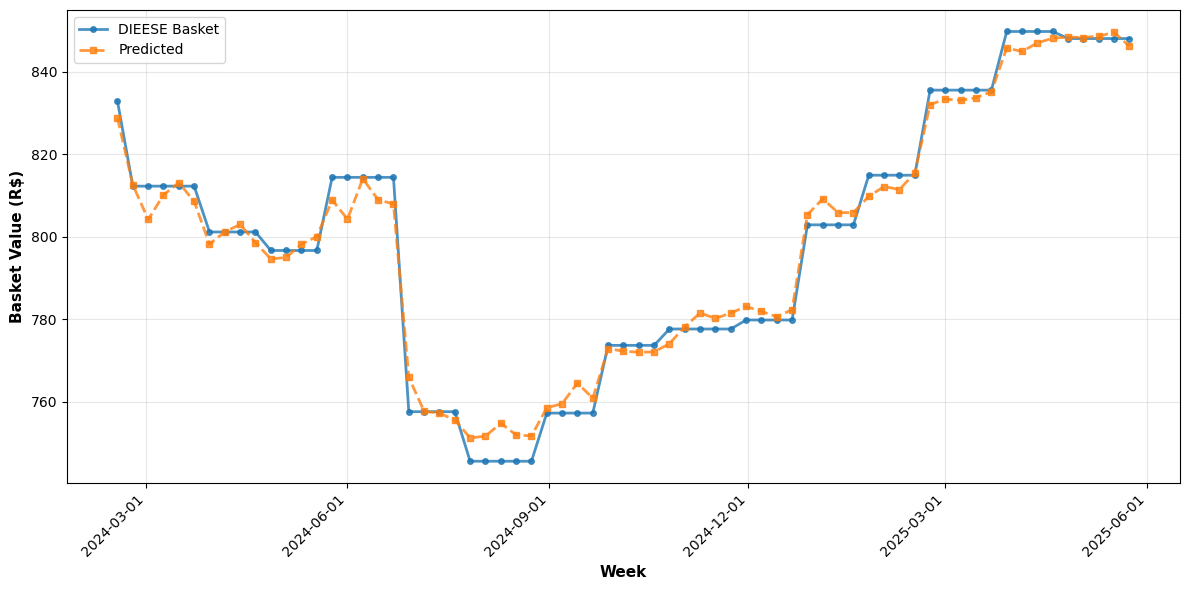

In [39]:
# Pegar datas originais do DataFrame (alinhadas com y)
dates = pd.to_datetime(df['week'].values[:len(y)])
 
# Gráfico de Série Temporal
plt.figure(figsize=(12, 6))
plt.plot(dates, y, 'o-', label='DIEESE Basket', linewidth=2, markersize=4, color='#1f77b4', alpha=0.8)
plt.plot(dates, y_pred, 's--', label='Predicted', linewidth=2, markersize=4, color='#ff7f0e', alpha=0.8)
plt.xlabel('Week', fontsize=11, fontweight='bold')
plt.ylabel('Basket Value (R$)', fontsize=11, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
 
# Formatar datas no eixo X
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')
 
plt.tight_layout()
plt.show()